# What is a Flowsheet? (Advanced)

**Prerequisites:** 00a_basic, 00b_intermediate

**Learning Objectives:**
- Understand flowsheets as computational graphs
- Learn the difference between sequential modular and equation-oriented approaches
- See why recycles require iteration
- Understand how information flows through a flowsheet

---

## The Computational Graph Perspective

We've seen flowsheets as:
1. **Pictures** (boxes and arrows)
2. **Systems of equations** (variables and constraints)

Now we'll see them as **computational graphs** - directed networks where:
- **Nodes** = unit operations (functions)
- **Edges** = streams (data flow)

This perspective is crucial for understanding:
- How simulators work
- Why some flowsheets are easy to solve and others are hard
- How automatic differentiation works

In [1]:
# Setup
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)

from difflow import make_stream, get_flows, combine_streams, total_flow
from difflow import CSTR, CSTRParams, Flash, FlashParams, IdealThermo, SpeciesData
from difflow.units.heat_exchanger import Heater, HeaterParams
from difflow.units.flash import Mixer

## Directed Acyclic Graphs (DAGs)

The simplest flowsheets are **DAGs** - graphs with no cycles:

```
    Feed ──► Unit 1 ──► Unit 2 ──► Unit 3 ──► Product
```

**Key property:** Information flows in ONE direction.

To solve a DAG flowsheet:
1. Start with the feed (known)
2. Compute Unit 1's output from its input
3. Compute Unit 2's output from its input (Unit 1's output)
4. Continue until you reach the product

This is called **sequential modular** simulation.

In [2]:
# Example: A DAG flowsheet
# Feed -> Heater -> Reactor -> Product

# Define species
species_data = {
    'A': SpeciesData(name='A', MW=50.0, Cp_coeffs=(50.0, 0, 0, 0),
                    Hvap_coeffs=(30000.0, 0.38, 400.0),
                    antoine_coeffs=(10.0, 2000.0, -40.0), Hf=0.0),
    'B': SpeciesData(name='B', MW=50.0, Cp_coeffs=(50.0, 0, 0, 0),
                    Hvap_coeffs=(30000.0, 0.38, 400.0),
                    antoine_coeffs=(10.0, 1800.0, -40.0), Hf=-20000.0),
}
thermo = IdealThermo(species_data)
species_order = ['A', 'B']

# Create unit operations
heater_params = HeaterParams(duty=10000.0, Cp=50.0)  # 10 kW heating, 50 J/mol·K
heater = Heater(heater_params)

def rate_fn(C, T, params):
    """Temperature independent rate constant. 
    You could include Arrhenius dependence here.
    """
    k = params['k']
    return jnp.array([k * C['A']])

stoich = jnp.array([[-1.0], [1.0]])  # A -> B

cstr_params = CSTRParams(
    V=jnp.array(1.0),
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={'k': jnp.array(0.5)},
    species_order=species_order,
)
reactor = CSTR(cstr_params, thermo=thermo, mode='isothermal')

In [3]:
# Sequential modular solution - just call units in order!

# Step 1: Start with feed (KNOWN)
feed = make_stream({'A': 10.0, 'B': 0.0}, T=300.0, P=101325.0)
print("Step 1: Feed stream (KNOWN)")
print(f"  F_A = {float(get_flows(feed)['A']):.2f} mol/s, T = {float(feed['T']):.0f} K")

# Step 2: Heater output = f(feed)
heater_out, _ = heater(feed)  # duty was set in HeaterParams
print("\nStep 2: Heater output = f(feed)")
print(f"  F_A = {float(get_flows(heater_out)['A']):.2f} mol/s, T = {float(heater_out['T']):.0f} K")

# Step 3: Reactor output = f(heater output)
reactor_out, reactor_info = reactor(heater_out, T_spec=float(heater_out['T']), volumetric_flow=0.1)
print("\nStep 3: Reactor output = f(heater output)")
print(f"  F_A = {float(get_flows(reactor_out)['A']):.2f} mol/s")
print(f"  F_B = {float(get_flows(reactor_out)['B']):.2f} mol/s")
print(f"  Conversion = {float(reactor_info['conversion']['A'])*100:.1f}%")

print("\n✓ DAG flowsheet solved in one forward pass!")

Step 1: Feed stream (KNOWN)
  F_A = 10.00 mol/s, T = 300 K

Step 2: Heater output = f(feed)
  F_A = 10.00 mol/s, T = 320 K



Step 3: Reactor output = f(heater output)
  F_A = 1.67 mol/s
  F_B = 8.33 mol/s
  Conversion = 83.3%

✓ DAG flowsheet solved in one forward pass!


## Cyclic Graphs (Recycles)

Real processes often have **recycles** - streams that loop back:

```
              ┌─────────────────────────┐
              │         Recycle         │
              ▼                         │
    Feed ──► Mixer ──► Reactor ──► Separator ──► Product
```

**Problem:** The recycle stream's composition depends on the separator output, which depends on the reactor output, which depends on the mixer output, which depends on the recycle stream!

$$\text{Recycle} = f(\text{Separator output}) = f(f(f(\text{Recycle})))$$

This is a **circular dependency** - we can't solve it in one forward pass.

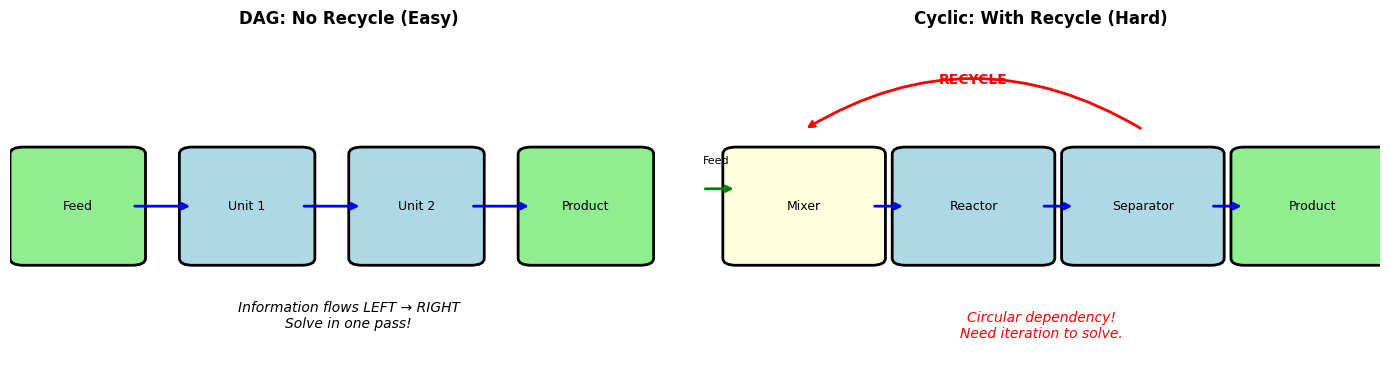

In [4]:
# Visualize why recycles are problematic
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: DAG (easy)
ax = axes[0]
ax.set_title('DAG: No Recycle (Easy)', fontsize=12, fontweight='bold')

# Boxes
for i, (x, name) in enumerate([(0.1, 'Feed'), (0.35, 'Unit 1'), (0.6, 'Unit 2'), (0.85, 'Product')]):
    color = 'lightgreen' if name in ['Feed', 'Product'] else 'lightblue'
    box = patches.FancyBboxPatch((x-0.08, 0.35), 0.16, 0.3,
        boxstyle="round,pad=0.02", facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(box)
    ax.text(x, 0.5, name, ha='center', va='center', fontsize=9)

# Arrows
for x1, x2 in [(0.18, 0.27), (0.43, 0.52), (0.68, 0.77)]:
    ax.annotate('', xy=(x2, 0.5), xytext=(x1, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='blue'))

ax.text(0.5, 0.15, 'Information flows LEFT → RIGHT\nSolve in one pass!', 
        ha='center', fontsize=10, style='italic')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Right: Cyclic (hard)
ax = axes[1]
ax.set_title('Cyclic: With Recycle (Hard)', fontsize=12, fontweight='bold')

# Boxes
positions = [(0.15, 'Mixer'), (0.4, 'Reactor'), (0.65, 'Separator'), (0.9, 'Product')]
for x, name in positions:
    color = 'lightgreen' if name == 'Product' else 'lightyellow' if name == 'Mixer' else 'lightblue'
    box = patches.FancyBboxPatch((x-0.1, 0.35), 0.2, 0.3,
        boxstyle="round,pad=0.02", facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(box)
    ax.text(x, 0.5, name, ha='center', va='center', fontsize=9)

# Forward arrows
for x1, x2 in [(0.25, 0.30), (0.50, 0.55), (0.75, 0.80)]:
    ax.annotate('', xy=(x2, 0.5), xytext=(x1, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='blue'))

# Feed arrow
ax.annotate('', xy=(0.05, 0.55), xytext=(0.0, 0.55),
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))
ax.text(0.0, 0.62, 'Feed', fontsize=8)

# Recycle arrow (the problem!)
ax.annotate('', xy=(0.15, 0.72), xytext=(0.65, 0.72),
            arrowprops=dict(arrowstyle='->', lw=2, color='red',
                          connectionstyle='arc3,rad=0.3'))
ax.text(0.4, 0.85, 'RECYCLE', ha='center', fontsize=10, color='red', fontweight='bold')

ax.text(0.5, 0.12, 'Circular dependency!\nNeed iteration to solve.', 
        ha='center', fontsize=10, style='italic', color='red')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

## Solving Recycles: Fixed-Point Iteration

To solve a recycle, we need to find a **fixed point** - a recycle stream value that, when processed through the flowsheet, produces itself:

$$\text{Recycle}^* = f(\text{Recycle}^*)$$

**Algorithm:**
1. Guess an initial recycle stream: $\text{Recycle}^{(0)}$
2. Compute the flowsheet: $\text{Recycle}^{(1)} = f(\text{Recycle}^{(0)})$
3. If $\text{Recycle}^{(1)} \approx \text{Recycle}^{(0)}$, we're done!
4. Otherwise, set $\text{Recycle}^{(0)} = \text{Recycle}^{(1)}$ and go to step 2

This is called **successive substitution** or **direct substitution**.

In [5]:
# Let's implement a simple recycle loop manually
# Reactor -> Separator -> (Recycle back to reactor inlet)

# Setup units
species_data_flash = {
    'A': SpeciesData(name='A', MW=50.0, Cp_coeffs=(50.0, 0, 0, 0),
                    Hvap_coeffs=(30000.0, 0.38, 400.0),
                    antoine_coeffs=(10.0, 2000.0, -40.0), Hf=0.0),  # Less volatile
    'B': SpeciesData(name='B', MW=50.0, Cp_coeffs=(50.0, 0, 0, 0),
                    Hvap_coeffs=(25000.0, 0.38, 380.0),
                    antoine_coeffs=(10.0, 1600.0, -40.0), Hf=-20000.0),  # More volatile
}
thermo_flash = IdealThermo(species_data_flash)

# Reactor: A -> B
cstr_params_recycle = CSTRParams(
    V=jnp.array(2.0),
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={'k': jnp.array(0.3)},
    species_order=species_order,
)
reactor_recycle = CSTR(cstr_params_recycle, thermo=thermo_flash, mode='isothermal')

# Flash separator
flash_params = FlashParams(species_order=species_order)
flash = Flash(flash_params, thermo=thermo_flash)

# Mixer
mixer = Mixer(species_order, thermo=thermo_flash)

In [6]:
# Manual fixed-point iteration

def one_flowsheet_iteration(recycle_guess, fresh_feed):
    """
    One iteration through the flowsheet.
    Returns the NEW recycle stream (liquid from flash).
    """
    # Mix fresh feed with recycle
    reactor_inlet, _ = mixer(fresh_feed, recycle_guess)
    
    # React
    reactor_out, _ = reactor_recycle(reactor_inlet, T_spec=368.0, volumetric_flow=0.1)
    
    # Separate at T=368K for good vapor/liquid split (vapor = product, liquid = recycle)
    liquid, vapor, _ = flash(reactor_out, T=368.0, P=101325.0)
    
    return liquid, vapor


# Fresh feed
fresh_feed = make_stream({'A': 10.0, 'B': 0.0}, T=300.0, P=101325.0)

# Initial guess for recycle (start with small values)
recycle = make_stream({'A': 1.0, 'B': 0.1}, T=368.0, P=101325.0)

print("Fixed-Point Iteration for Recycle Convergence")
print("=" * 60)

for iteration in range(20):
    # Save old values
    old_A = float(get_flows(recycle)['A'])
    old_B = float(get_flows(recycle)['B'])
    
    # One iteration
    new_recycle, product = one_flowsheet_iteration(recycle, fresh_feed)
    
    # New values
    new_A = float(get_flows(new_recycle)['A'])
    new_B = float(get_flows(new_recycle)['B'])
    
    # Check convergence
    change_A = abs(new_A - old_A)
    change_B = abs(new_B - old_B)
    max_change = max(change_A, change_B)
    
    print(f"Iter {iteration+1:2d}: Recycle F_A={new_A:8.4f}, F_B={new_B:8.4f}, Change={max_change:.2e}")
    
    if max_change < 1e-6:
        print(f"\n✓ Converged after {iteration+1} iterations!")
        break
    
    # Update for next iteration (with damping for stability)
    damping = 0.5
    recycle = make_stream(
        {'A': old_A + damping * (new_A - old_A),
         'B': old_B + damping * (new_B - old_B)},
        T=368.0, P=101325.0
    )

print(f"\nFinal recycle: F_A={float(get_flows(recycle)['A']):.4f}, F_B={float(get_flows(recycle)['B']):.4f} mol/s")
print(f"Product (vapor): F_A={float(get_flows(product)['A']):.4f}, F_B={float(get_flows(product)['B']):.4f} mol/s")

Fixed-Point Iteration for Recycle Convergence


Iter  1: Recycle F_A=  1.4689, F_B=  4.4145, Change=4.31e+00


Iter  2: Recycle F_A=  1.4539, F_B=  4.3660, Change=2.11e+00


Iter  3: Recycle F_A=  1.4460, F_B=  4.3417, Change=1.03e+00


Iter  4: Recycle F_A=  1.4418, F_B=  4.3288, Change=5.02e-01


...

Iter 16: Recycle F_A=  1.4369, F_B=  4.3141, Change=6.35e-05


Iter 17: Recycle F_A=  1.4369, F_B=  4.3141, Change=2.80e-05


Iter 18: Recycle F_A=  1.4369, F_B=  4.3141, Change=1.21e-05


Iter 19: Recycle F_A=  1.4369, F_B=  4.3141, Change=4.97e-06


Iter 20: Recycle F_A=  1.4369, F_B=  4.3141, Change=1.92e-06

Final recycle: F_A=1.4369, F_B=4.3141 mol/s
Product (vapor): F_A=0.1970, F_B=9.8030 mol/s


## Two Approaches to Flowsheet Simulation

### 1. Sequential Modular (SM)

**Idea:** Each unit is a "black box" module. Solve units one at a time.

**Advantages:**
- Easy to implement and understand
- Each unit is independent
- Can use different models for different units

**Disadvantages:**
- Recycles require iteration
- Can be slow to converge
- Difficult to add constraints across units

**Used by:** Aspen Plus, HYSYS (historically)

### 2. Equation-Oriented (EO)

**Idea:** Write ALL equations for ALL units simultaneously. Solve the entire system at once.

**Advantages:**
- No iteration needed for recycles
- Can add any constraint
- Faster convergence for complex systems

**Disadvantages:**
- Need good initial guesses for everything
- Harder to debug
- Memory-intensive for large systems

**Used by:** gPROMS, modern optimization solvers

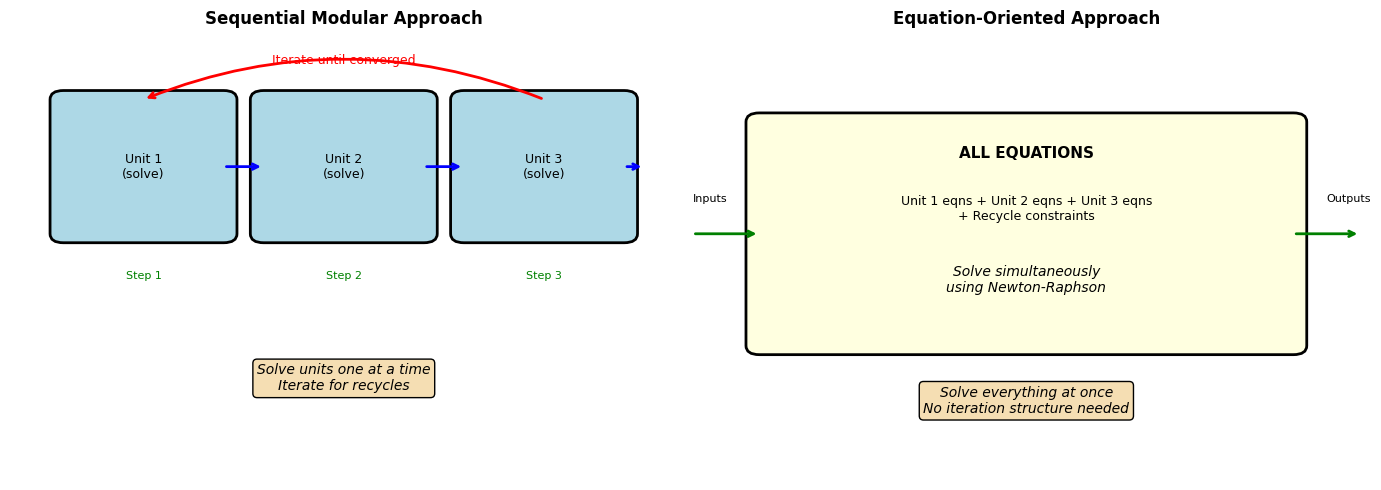

In [7]:
# Visualize the two approaches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sequential Modular
ax = axes[0]
ax.set_title('Sequential Modular Approach', fontsize=12, fontweight='bold')

# Draw unit boxes
for i, (x, y, name) in enumerate([(0.2, 0.7, 'Unit 1'), (0.5, 0.7, 'Unit 2'), (0.8, 0.7, 'Unit 3')]):
    box = patches.FancyBboxPatch((x-0.12, y-0.15), 0.24, 0.3,
        boxstyle="round,pad=0.02", facecolor='lightblue', edgecolor='black', linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, f'{name}\n(solve)', ha='center', va='center', fontsize=9)
    ax.text(x, y-0.25, f'Step {i+1}', ha='center', fontsize=8, color='green')

# Arrows
for x1, x2 in [(0.08, 0.08), (0.32, 0.38), (0.62, 0.68)]:
    ax.annotate('', xy=(x2, 0.7), xytext=(x1, 0.7),
                arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
ax.annotate('', xy=(0.95, 0.7), xytext=(0.92, 0.7),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))

# Recycle
ax.annotate('', xy=(0.2, 0.85), xytext=(0.8, 0.85),
            arrowprops=dict(arrowstyle='->', lw=2, color='red',
                          connectionstyle='arc3,rad=0.2'))
ax.text(0.5, 0.93, 'Iterate until converged', ha='center', fontsize=9, color='red')

ax.text(0.5, 0.2, 'Solve units one at a time\nIterate for recycles', 
        ha='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat'))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Equation-Oriented
ax = axes[1]
ax.set_title('Equation-Oriented Approach', fontsize=12, fontweight='bold')

# Big box containing all equations
big_box = patches.FancyBboxPatch((0.1, 0.3), 0.8, 0.5,
    boxstyle="round,pad=0.02", facecolor='lightyellow', edgecolor='black', linewidth=2)
ax.add_patch(big_box)

ax.text(0.5, 0.72, 'ALL EQUATIONS', ha='center', fontsize=11, fontweight='bold')
ax.text(0.5, 0.58, 'Unit 1 eqns + Unit 2 eqns + Unit 3 eqns\n+ Recycle constraints', 
        ha='center', fontsize=9)
ax.text(0.5, 0.42, 'Solve simultaneously\nusing Newton-Raphson', 
        ha='center', fontsize=10, style='italic')

# Input/output arrows
ax.annotate('', xy=(0.1, 0.55), xytext=(0.0, 0.55),
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))
ax.text(0.0, 0.62, 'Inputs', fontsize=8)

ax.annotate('', xy=(1.0, 0.55), xytext=(0.9, 0.55),
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))
ax.text(0.95, 0.62, 'Outputs', fontsize=8)

ax.text(0.5, 0.15, 'Solve everything at once\nNo iteration structure needed', 
        ha='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat'))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

## Where difflow Fits In

**difflow uses a hybrid approach:**

1. Units are **sequential modular** (each unit is a function)
2. Recycles are solved by **fixed-point iteration**
3. The iteration is implemented using **JAX's `lax.scan`**
4. This makes the entire flowsheet **differentiable** (!)  

The key insight: even though we iterate for recycles, JAX can differentiate *through* the iteration using implicit differentiation.

This gives us:
- The simplicity of sequential modular
- The differentiability needed for optimization
- Exact gradients (not finite differences)

In [8]:
# Using optimistix for fixed-point iteration
import optimistix as optx

def flowsheet_step(recycle_arr, args):
    """One iteration of the flowsheet, returning the new recycle as an array."""
    fresh_feed = args
    
    # Unpack recycle array
    recycle = make_stream(
        {'A': recycle_arr[0], 'B': recycle_arr[1]},
        T=368.0, P=101325.0
    )
    
    # Process flowsheet
    reactor_inlet, _ = mixer(fresh_feed, recycle)
    reactor_out, _ = reactor_recycle(reactor_inlet, T_spec=368.0, volumetric_flow=0.1)
    liquid, vapor, _ = flash(reactor_out, T=368.0, P=101325.0)
    
    # Return new recycle as array
    return jnp.array([liquid['F_A'], liquid['F_B']])


# Solve using optimistix fixed-point solver
fresh_feed = make_stream({'A': 10.0, 'B': 0.0}, T=300.0, P=101325.0)
initial_guess = jnp.array([1.0, 0.1])

fp_solver = optx.FixedPointIteration(rtol=1e-8, atol=1e-8)
sol = optx.fixed_point(
    flowsheet_step,
    fp_solver,
    initial_guess,
    args=fresh_feed,
    max_steps=100,
    throw=False,
)
converged_recycle = sol.value

print("Optimistix Fixed-Point Solver Result")
print("=" * 40)
print(f"Converged recycle: F_A = {float(converged_recycle[0]):.4f} mol/s")
print(f"                   F_B = {float(converged_recycle[1]):.4f} mol/s")

# Final pass to show product
recycle_final = make_stream({'A': converged_recycle[0], 'B': converged_recycle[1]}, T=368.0, P=101325.0)
inlet_final, _ = mixer(fresh_feed, recycle_final)
out_final, _ = reactor_recycle(inlet_final, T_spec=368.0, volumetric_flow=0.1)
_, product, _ = flash(out_final, T=368.0, P=101325.0)
print(f"\nProduct (vapor):   F_A = {float(get_flows(product)['A']):.4f} mol/s")
print(f"                   F_B = {float(get_flows(product)['B']):.4f} mol/s")

Optimistix Fixed-Point Solver Result
Converged recycle: F_A = 1.4369 mol/s
                   F_B = 4.3141 mol/s



Product (vapor):   F_A = 0.1970 mol/s
                   F_B = 9.8030 mol/s


## Information Flow and Causality

Understanding information flow helps debug flowsheets:

**Question:** If I change parameter X, what outputs are affected?

**Answer:** Trace the computational graph forward from X.

For example, in a reactor-separator-recycle system:
- Change reactor temperature → affects reactor output → affects separator → affects recycle → affects reactor inlet → ... (everything changes!)
- Change separator temperature → affects separator only → affects recycle → affects reactor inlet → affects reactor output → ... (everything downstream changes)

With recycles, **everything affects everything** through the loop.

In [9]:
# Demonstrate information flow with a sensitivity analysis

def flowsheet_product_B(params):
    """Compute product B flow as a function of parameters."""
    T_reactor = params['T_reactor']
    T_flash = params['T_flash']
    
    # Create reactor with temperature-dependent rate
    def rate_fn_T(C, T, p):
        # Arrhenius: k = A * exp(-Ea/RT)
        k = p['A'] * jnp.exp(-p['Ea'] / (8.314 * T))
        return jnp.array([k * C['A']])
    
    cstr_p = CSTRParams(
        V=jnp.array(2.0),
        rate_fn=rate_fn_T,
        stoich=stoich,
        rate_params={'A': jnp.array(1e6), 'Ea': jnp.array(40000.0)},
        species_order=species_order,
    )
    reactor_p = CSTR(cstr_p, thermo=thermo_flash, mode='isothermal')
    
    def step(recycle_arr, args):
        fresh = args
        recycle = make_stream({'A': recycle_arr[0], 'B': recycle_arr[1]}, T=T_flash, P=101325.0)
        inlet, _ = mixer(fresh, recycle)
        out, _ = reactor_p(inlet, T_spec=T_reactor, volumetric_flow=0.1)
        liq, vap, _ = flash(out, T=T_flash, P=101325.0)
        return jnp.array([liq['F_A'], liq['F_B']])
    
    fresh = make_stream({'A': 10.0, 'B': 0.0}, T=300.0, P=101325.0)
    
    # Use optimistix for fixed-point iteration
    fp_solver = optx.FixedPointIteration(rtol=1e-8, atol=1e-8)
    sol = optx.fixed_point(step, fp_solver, jnp.array([1.0, 0.1]), args=fresh, max_steps=100, throw=False)
    converged = sol.value
    
    # Final pass to get product
    recycle_final = make_stream({'A': converged[0], 'B': converged[1]}, T=T_flash, P=101325.0)
    inlet_final, _ = mixer(fresh, recycle_final)
    out_final, _ = reactor_p(inlet_final, T_spec=T_reactor, volumetric_flow=0.1)
    _, product, _ = flash(out_final, T=T_flash, P=101325.0)
    
    return product['F_B']


# Compute sensitivities - use T_flash=368K for good separation
params = {'T_reactor': jnp.array(368.0), 'T_flash': jnp.array(368.0)}

F_B = flowsheet_product_B(params)
print("Information Flow Analysis")
print("=" * 50)
print(f"Product B flow: {float(F_B):.4f} mol/s")
print()

# Try to compute gradients - this may fail due to numerical issues
try:
    grads = jax.grad(lambda p: flowsheet_product_B(p))(params)
    print(f"Sensitivities (how much F_B changes per K):")
    print(f"  dF_B/dT_reactor = {float(grads['T_reactor']):.6f} mol/s/K")
    print(f"  dF_B/dT_flash   = {float(grads['T_flash']):.6f} mol/s/K")
    print()
    print("Interpretation:")
    print(f"  +1K in reactor temp -> {float(grads['T_reactor']):.4f} mol/s more B")
    print(f"  +1K in flash temp   -> {float(grads['T_flash']):.4f} mol/s more B")
except Exception as e:
    print("Gradient computation failed!")
    print(f"Error type: {type(e).__name__}")
    print()
    print("This is a known numerical issue - see discussion below.")

Information Flow Analysis
Product B flow: 9.7674 mol/s



Sensitivities (how much F_B changes per K):
  dF_B/dT_reactor = 0.008071 mol/s/K
  dF_B/dT_flash   = -0.000006 mol/s/K

Interpretation:
  +1K in reactor temp -> 0.0081 mol/s more B
  +1K in flash temp   -> -0.0000 mol/s more B


## A Note on Numerical Challenges with Implicit Differentiation

The code above may fail when computing gradients through the fixed-point iteration. This is a **real challenge** in differentiable process simulation that's worth understanding.

### What's Happening?

When we use `jax.grad()` on a function that contains a fixed-point iteration, JAX uses **implicit differentiation** rather than unrolling all the iterations. The implicit function theorem says:

If $x^* = f(x^*, \theta)$ (the fixed-point condition), then:

$$\frac{dx^*}{d\theta} = \left(I - \frac{\partial f}{\partial x}\Big|_{x^*}\right)^{-1} \frac{\partial f}{\partial \theta}\Big|_{x^*}$$

This requires **inverting** the matrix $(I - \partial f/\partial x)$. When this matrix is singular or nearly singular (has eigenvalues near 1), the inversion fails or produces NaN/inf values.

### Why Does This Happen in Flowsheets?

Several flowsheet characteristics can cause numerical issues:

1. **Near-complete reactions**: When conversion approaches 100%, small changes in input produce negligible changes in output, making the Jacobian nearly singular.

2. **Phase equilibrium near boundaries**: When a flash drum operates near the bubble or dew point, the vapor fraction changes sharply, creating numerical sensitivity.

3. **Recycle ratios**: High recycle ratios (recycle >> fresh feed) can amplify numerical errors through the loop.

4. **Stiff systems**: When some parts of the flowsheet equilibrate much faster than others.

### Ways to Address This

1. **Use finite differences for problematic cases**:
   ```python
   eps = 1e-6
   dF_dT = (flowsheet(T + eps) - flowsheet(T)) / eps
   ```
   Less accurate but more robust.

2. **Regularize the problem**: Add small perturbations to prevent exact singularities.

3. **Better initial guesses**: Starting closer to the solution can help the iteration converge to a numerically stable fixed point.

4. **Change solver settings**: Use `lineax.AutoLinearSolver(well_posed=False)` for least-squares solutions.

5. **Reformulate the flowsheet**: Sometimes restructuring which variables are iterated can improve conditioning.

### Consequences of Not Addressing This

- **Optimization fails**: Gradient-based optimizers can't proceed without reliable gradients.
- **Sensitivity analysis unreliable**: Reported sensitivities may be wrong or infinite.
- **Uncertainty propagation breaks**: Linear propagation requires valid gradients.

**Important**: The *forward simulation* still works correctly! You can always compute the flowsheet outputs. The issue is only with computing gradients through the converged solution.

In practice, many industrial-strength process simulators use finite differences or adjoint methods with careful numerical handling for sensitivity analysis. The challenge of differentiating through iterative solvers is an active area of research.

## Try It Yourself!

### Exercise 1: Trace Information Flow

Consider this flowsheet:
```
Feed A ──► Reactor ──► Flash ──► Product B (vapor)
                         │
                         └──► Liquid (waste)
```

If you increase the feed flow rate, which streams are affected? List them in order.

*Your answer:*



### Exercise 2: Identify Recycles

In a typical ammonia plant:
```
N2 + 3H2 ⇌ 2NH3  (equilibrium limited, ~15% conversion per pass)
```

The flowsheet is:
```
Fresh N2/H2 ──► Compressor ──► Reactor ──► Cooler ──► Separator ──► NH3 Product
      ▲                                        │
      └────────────── Unreacted N2/H2 ─────────┘
```

Why is the recycle necessary? What would happen without it?

*Your answer:*



### Exercise 3: Convergence Behavior

Run the fixed-point iteration code above with different damping factors (0.1, 0.3, 0.5, 0.7, 0.9). What do you observe about:
- Number of iterations to converge?
- Stability of the iteration?

In [10]:
# Your experiments here

## End-of-Tutorial Problems

### Problem 1: Graph Classification

Classify each of these flowsheets as DAG or Cyclic:

a) Feed → Reactor → Distillation → Product

b) Feed → Reactor → Flash → Product, with liquid recycled to reactor

c) Feed → Heat Exchanger 1 → Reactor → Heat Exchanger 2 → Product, 
   where HX1 and HX2 share a utility stream

d) Feed → Reactor 1 → Reactor 2 → Separator → Product,
   with separator liquid to Reactor 1 and separator vapor to Reactor 2

*Your answers:*



### Problem 2: Why Iteration?

Explain in your own words why we can't solve a recycle flowsheet in one forward pass. Use the concept of "circular dependency."

*Your answer:*



### Problem 3: SM vs EO Trade-offs

You're designing a simulation for:
a) A simple 3-unit process with no recycles
b) A complex refinery with 50 units and 10 recycle loops

Which approach (Sequential Modular or Equation-Oriented) would you recommend for each? Justify your answer.

*Your answers:*



---

## Key Takeaways

1. **Flowsheets are computational graphs** - Information flows through nodes (units) along edges (streams)
2. **DAGs are easy** - Solve in one forward pass
3. **Recycles create cycles** - Need iteration to find a consistent solution
4. **Fixed-point iteration** - Guess → Compute → Check → Repeat
5. **Two main approaches**: Sequential Modular (unit by unit) vs Equation-Oriented (all at once)
6. **difflow is differentiable** - Even through recycle iteration!

---

## Next Steps

Now that you understand what flowsheets are at all three levels (physical, mathematical, computational), we'll dive into specific unit operations:

**00d: Single Unit - The CSTR** - Derive and implement reactor equations from first principles.